In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Quadratic Regulator

Convergence boils down to the convex cost function built on the quadratic matrices. 

In this notebook we determine the optimal gains for a PD controller by recursively calling the Algebraic Riccati Equation. This is an implementation fo LQR, as we minimize a Quadratic Cost Function to determine this controller.



Further Research:
1. Least-norm input, least-squares .
    Use a QR solver to work backwards in order to solve the QP by substitution.
2. regularized least-squares, gauss newton method(https://see.stanford.edu/materials/lsoeldsee263/07-ls-reg.pdf)
3. Connection to Reinforcement Learning.
    value function, bellman dp
4. LQR solved through Dynamic Programming.
    Recursively solve the traveling salesman problem to find the shortest route given the cost-to-go function.

### LQR as a steady-state regulator. 
Use LQR to determine the optimal gains for a PD controller, with a simple example in matrix form (Ax + Bu)

In [3]:
# Problem Defn Setup
A = np.array([[1, 1], [0, 1]])
B = np.array([[0], [1]])
C = np.array([[1, 0]])

x_t1 = np.array([[0], [0]])  # Initial state
x_t2 = A @ x_t1 + B @ np.array([[1]])  # Control input u = 1

Q = C.T @ C  # Cost matrix for state
R = np.array([[1]])  # Cost matrix for control input

In [4]:
P = Q  # Initialize P matrix

for i in range(10):  # Iterative DP
    #print(f"Iteration {i+1}: P = {P}")
    P = Q + A.T @ P @ A - A.T @ P @ B @ np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A

K = np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A  # Gain matrix

print("Gain Matrix K:", K)


Gain Matrix K: [[0.48053368 1.24962028]]


In the above snippet of code we:
1. Initialize the P matrix to equal the Cost of the State(Q)
2. Use the Algebraic Riccati Equation(ARE) to recursively determine the steady-state P matrix
3. For t not close to N,(for a generalization of states), we determine the optimal input as a linear and constant state feedback (u = K * x)

In [10]:
# Run the Simulation
x_d = np.array([[1], [0]])  # Desired state

x = np.array([[0], [0]])  # Current state

for i in range(10):
    x_curr = x[:, -1].reshape(2, 1)

    e = x_d - x_curr

    x_new = A @ x_curr + B @ (K @ e)  # Update state with LQR control

    x = np.hstack((x, x_new))  # Append new state to history

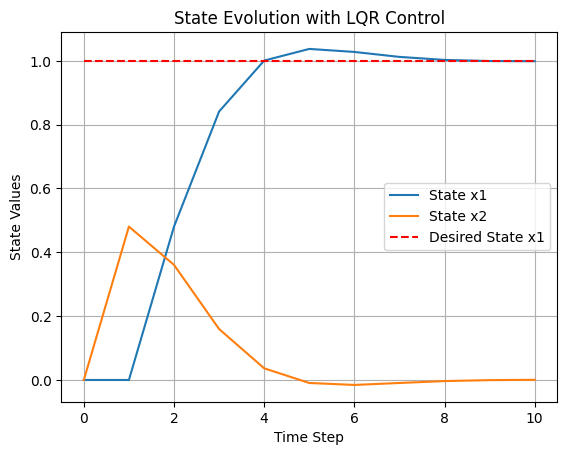

In [11]:
# Plot the results
plt.plot(x[0, :], label='State x1')
plt.plot(x[1, :], label='State x2')
plt.hlines(x_d[0], xmin=0, xmax=i+1, color='red', linestyle='--', label='Desired State x1')
plt.legend()
plt.xlabel('Time Step')
plt.ylabel('State Values')
plt.title('State Evolution with LQR Control')
plt.grid()

To Do:

2. Add a conclusion or reflection about state accuracy and acuator effort
3. Add connection to RL
4. Add connection to MPC
5. How do we implement an LQR trained controller on the ACS example(what about MPC?)